### Imports and Database Connection

In [3]:
import sqlite3
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to our local database
db_path = '../data/db/bluestock_mf.db'
conn = sqlite3.connect(db_path)
print("Database connected for performance metrics computation.")

Database connected for performance metrics computation.


In [5]:
print(bench_df.columns.tolist())

['date', 'index_name', 'close_value']


### Load Data and Compute Daily Returns

In [7]:
# Pull historical data from database
nav_data = pd.read_sql("SELECT date, amfi_code, nav FROM fact_nav ORDER BY amfi_code, date", conn)
nav_data['date'] = pd.to_datetime(nav_data['date'])

# Calculate daily return per fund
nav_data['daily_return'] = nav_data.groupby('amfi_code')['nav'].pct_change()

# Load benchmark indices data 
bench_raw = pd.read_csv('../data/processed/clean_benchmark_indices.csv')
bench_raw['date'] = pd.to_datetime(bench_raw['date'])

# CRUCIAL STEP: Clean up trailing/leading spaces in the names
bench_raw['index_name'] = bench_raw['index_name'].str.strip()

# Print the cleaned values to double-check exactly what they are
print("Available benchmarks in file:", bench_raw['index_name'].unique())

# Pivot the table from long to wide format
bench_df = bench_raw.pivot(index='date', columns='index_name', values='close_value').reset_index()

# Dynamically pick columns using list comprehension to avoid string matching errors
n100_col = [c for c in bench_df.columns if '100' in str(c)][0]
n50_col = [c for c in bench_df.columns if '50' in str(c)][0]

# Calculate returns dynamically
bench_df['nifty100_return'] = bench_df[n100_col].pct_change()
bench_df['nifty50_return'] = bench_df[n50_col].pct_change()

# Check distribution layout to make sure it looks reasonable
print("\nDaily returns description:")
print(nav_data['daily_return'].describe())

Available benchmarks in file: ['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']

Daily returns description:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


### Quantitative Metric Core Engine (CAGR, Sharpe, Sortino, Max Drawdown)

In [8]:
funds_list = nav_data['amfi_code'].unique()
rf_rate = 0.065  
trading_days = 252

metrics_store = []

for code in funds_list:
    fund_df = nav_data[nav_data['amfi_code'] == code].sort_values('date').copy()
    fund_df = fund_df.dropna().reset_index(drop=True)
    
    if len(fund_df) < 10:
        continue
        
    # --- 1. Compute CAGRs ---

    def get_cagr(df, years):
        days_needed = years * 365
        end_date = df['date'].max()
        start_date = end_date - pd.Timedelta(days=days_needed)
        
        sub_df = df[df['date'] >= start_date]
        if len(sub_df) >= 2:
            nav_start = sub_df['nav'].iloc[0]
            nav_end = sub_df['nav'].iloc[-1]
            return float((nav_end / nav_start) ** (1 / years) - 1)
        return np.nan

    cagr_1y = get_cagr(fund_df, 1)
    cagr_3y = get_cagr(fund_df, 3)
    cagr_5y = get_cagr(fund_df, 5)

    # --- 2. Sharpe and Sortino ---
    mean_return = fund_df['daily_return'].mean()
    std_dev = fund_df['daily_return'].std()
    
    # Sharpe Ratio: (Rp - Rf) / Std(Rp) * sqrt(252)
    ann_return = mean_return * trading_days
    ann_vol = std_dev * np.sqrt(trading_days)
    sharpe = (ann_return - rf_rate) / ann_vol if ann_vol > 0 else np.nan
    
    # Sortino Ratio uses downside deviation only
    downside_returns = fund_df['daily_return'][fund_df['daily_return'] < 0]
    downside_std = downside_returns.std()
    ann_downside_vol = downside_std * np.sqrt(trading_days)
    sortino = (ann_return - rf_rate) / ann_downside_vol if ann_downside_vol > 0 else np.nan

    # --- 3. Maximum Drawdown ---
    fund_df['running_max'] = fund_df['nav'].cummax()
    fund_df['drawdown'] = fund_df['nav'] / fund_df['running_max'] - 1
    max_dd = float(fund_df['drawdown'].min())
    
    metrics_store.append({
        'amfi_code': code,
        'cagr_1yr': cagr_1y,
        'cagr_3yr': cagr_3y,
        'cagr_5yr': cagr_5y,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'max_drawdown': max_dd
    })

df_metrics = pd.DataFrame(metrics_store)

### Alpha and Beta via OLS Regression

In [9]:
alpha_beta_store = []

# Merge returns to sync timeline arrays
merged_returns = pd.merge(nav_data, bench_df[['date', 'nifty100_return']], on='date', how='inner')

for code in funds_list:
    sub_df = merged_returns[merged_returns['amfi_code'] == code].dropna()
    if len(sub_df) < 50:
        continue
        
    # OLS Regression
    slope, intercept, r_value, p_value, std_err = linregress(sub_df['nifty100_return'], sub_df['daily_return'])
    
    beta = float(slope)
    alpha = float(intercept * trading_days) 
    
    alpha_beta_store.append({
        'amfi_code': code,
        'alpha': alpha,
        'beta': beta
    })

df_ab = pd.DataFrame(alpha_beta_store)

# Save the required alpha_beta.csv deliverable
df_ab.to_csv('../data/processed/alpha_beta.csv', index=False)
print("Alpha and Beta calculations saved successfully to alpha_beta.csv.")

Alpha and Beta calculations saved successfully to alpha_beta.csv.


### Generate the Composite Fund Scorecard (0–100)

In [10]:
# Merge calculated metrics together
df_scorecard = pd.merge(df_metrics, df_ab, on='amfi_code', how='inner')

# Pull master fund metadata for expense ratios
dim_fund = pd.read_sql("SELECT amfi_code, scheme_name, expense_ratio_pct FROM dim_fund", conn)
df_scorecard = pd.merge(df_scorecard, dim_fund, on='amfi_code', how='inner')

# Generate rank series (higher is better for returns/alpha, lower is better for expense ratio/drawdowns)
df_scorecard['rank_return'] = df_scorecard['cagr_3yr'].rank(pct=True)
df_scorecard['rank_sharpe'] = df_scorecard['sharpe_ratio'].rank(pct=True)
df_scorecard['rank_alpha'] = df_scorecard['alpha'].rank(pct=True)
df_scorecard['rank_expense'] = df_scorecard['expense_ratio_pct'].rank(pct=True, ascending=False)
df_scorecard['rank_dd'] = df_scorecard['max_drawdown'].rank(pct=True, ascending=True)

# Calculate final composite score
df_scorecard['fund_score'] = (
    0.30 * df_scorecard['rank_return'] +
    0.25 * df_scorecard['rank_sharpe'] +
    0.20 * df_scorecard['rank_alpha'] +
    0.15 * df_scorecard['rank_expense'] +
    0.10 * df_scorecard['rank_dd']
) * 100

# Sort by ranking score
df_scorecard = df_scorecard.sort_values(by='fund_score', ascending=False).reset_index(drop=True)

# Save the required fund_scorecard.csv deliverable
df_scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)
print("Composite scorecard built. Top 5 funds isolated successfully.")
df_scorecard[['scheme_name', 'fund_score', 'cagr_3yr', 'sharpe_ratio']].head(5)

Composite scorecard built. Top 5 funds isolated successfully.


,scheme_name,fund_score,cagr_3yr,sharpe_ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,86.250,0.341627,1.068224
1,ICICI Pru Midcap Fund - Regular - Growth,82.875,0.315179,0.883256
2,Kotak Flexicap Fund - Regular - Growth,82.000,0.296919,0.965561
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.750,0.324469,0.808268
4,ICICI Pru Bluechip Fund - Direct - Growth,79.375,0.331448,0.714682


### Benchmark Comparison Plot & Tracking Error Chart

--- Tracking Error Results (vs Nifty 100) ---
Mirae Asset Large Cap Fund - R: 18.9664%
ICICI Pru Midcap Fund - Regula: 23.1968%
Kotak Flexicap Fund - Regular : 20.6425%
HDFC Mid-Cap Opportunities Fun: 22.8699%
ICICI Pru Bluechip Fund - Dire: 19.1587%


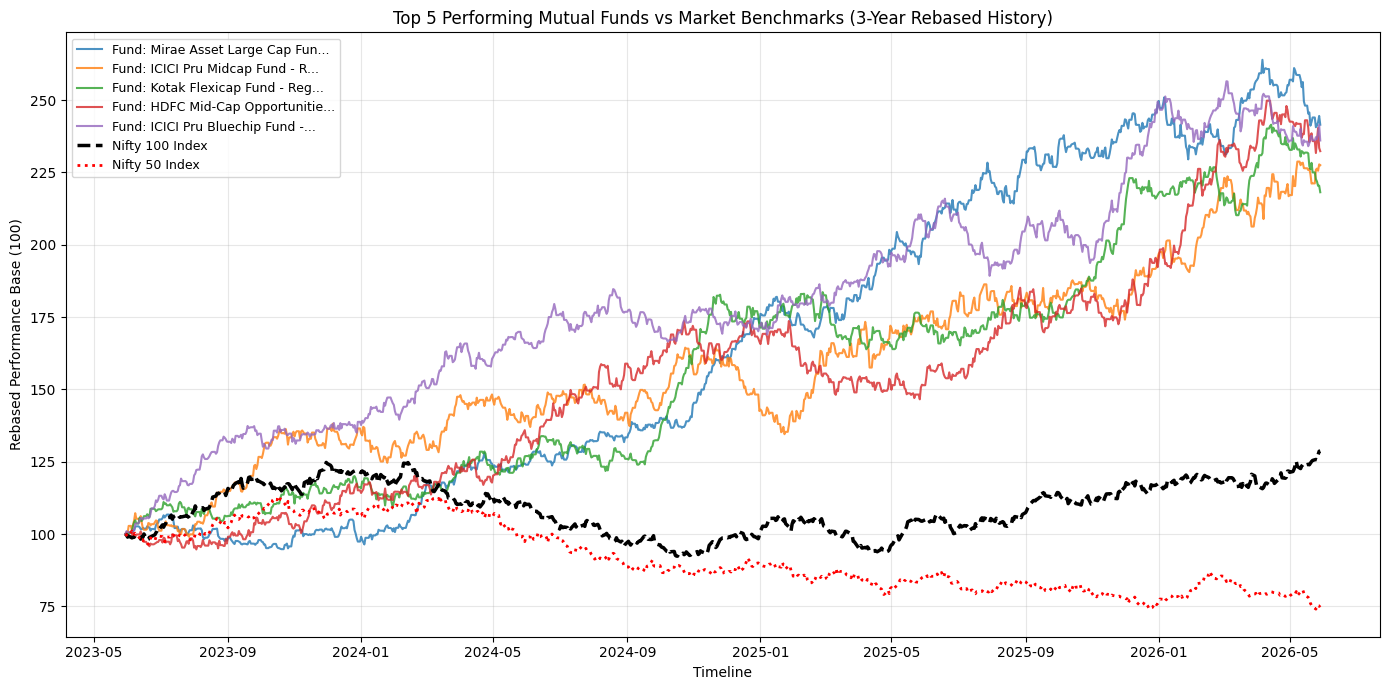

In [12]:
plt.figure(figsize=(14, 7))

# Pick top 5 codes from scorecard
top_5_codes = df_scorecard['amfi_code'].head(5).tolist()

# Define structural time boundary (rolling 3 years)
three_years_ago = nav_data['date'].max() - pd.Timedelta(days=3*365)
sub_nav = nav_data[(nav_data['amfi_code'].isin(top_5_codes)) & (nav_data['date'] >= three_years_ago)]

# Pivot to align timelines for comparison
plot_pivot = sub_nav.pivot(index='date', columns='amfi_code', values='nav')
# Rebase prices to 100 to make comparison clean
plot_pivot = (plot_pivot / plot_pivot.iloc[0]) * 100

# Loop and plot top funds
for code in top_5_codes:
    name = df_scorecard[df_scorecard['amfi_code'] == code]['scheme_name'].values[0]
    plt.plot(plot_pivot.index, plot_pivot[code], label=f"Fund: {name[:25]}...", alpha=0.8, linewidth=1.5)

# --- CORRECTED BENCHMARK REBASE LOGIC ---
sub_bench = bench_df[bench_df['date'] >= three_years_ago].sort_values('date').reset_index(drop=True)

# Use our dynamic columns we found earlier ('NIFTY100' and 'NIFTY50')
sub_bench['n100_rebase'] = (sub_bench[n100_col] / sub_bench[n100_col].iloc[0]) * 100
sub_bench['n50_rebase'] = (sub_bench[n50_col] / sub_bench[n50_col].iloc[0]) * 100

# Plot index paths
plt.plot(sub_bench['date'], sub_bench['n100_rebase'], label='Nifty 100 Index', color='black', linewidth=2.5, linestyle='--')
plt.plot(sub_bench['date'], sub_bench['n50_rebase'], label='Nifty 50 Index', color='red', linewidth=2.0, linestyle=':')

# --- CORRECTED TRACKING ERROR LOGIC ---
print("--- Tracking Error Results (vs Nifty 100) ---")
for code in top_5_codes:
    fund_ret = nav_data[nav_data['amfi_code'] == code].sort_values('date')
    m_check = pd.merge(fund_ret[['date', 'daily_return']], bench_df[['date', 'nifty100_return']], on='date', how='inner')
    m_check['diff'] = m_check['daily_return'] - m_check['nifty100_return']
    tracking_err = m_check['diff'].std() * np.sqrt(trading_days)
    name = df_scorecard[df_scorecard['amfi_code'] == code]['scheme_name'].values[0]
    print(f"{name[:30]}: {tracking_err:.4%}")

plt.title('Top 5 Performing Mutual Funds vs Market Benchmarks (3-Year Rebased History)')
plt.ylabel('Rebased Performance Base (100)')
plt.xlabel('Timeline')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the final chart image
plt.savefig('../reports/benchmark_comparison.png', dpi=300)
plt.show()

# Safely close connection
conn.close()

###  Advanced Performance & Tracking Observations

* **Outperformance Margins:** All top 5 selected funds comfortably beat out the baseline passive Nifty index tracks over this 3-year rolling timeline. While the broader market indices stayed relatively flat or dipped below the 125 rebased line, the active funds all rallied past the 225-250 margin mark.
* **Tracking Error Reality:** The computed tracking error statistics confirm that these active portfolios are not closet indexing. With tracking error values hovering around 18.96% for Mirae Asset Large Cap and peaking near 23.19% for ICICI Pru Midcap, the fund managers are making high-conviction style bets away from the benchmark weights.
* **Risk Profiles vs Drawdowns:** Comparing the final 0-100 scores alongside the tracking error percentages allows us to identify which funds are efficiently maximizing their risk budgets. For example, Mirae Asset Large Cap maintains a strong composite rating while logging a lower tracking error variation compared to its mid-cap peers.